# Question 1

## Part (c): Numerical Investigation of the Mathieu Equation

In this notebook, we will use numerical simulations to verify the analytical findings from parts (a) and (b) regarding the stability of the Mathieu equation:
$$\ddot{x} + c\dot{x} + (\omega^2 + \varepsilon \cos 2t)x = 0$$

Specifically, we will:
1. Verify the stability boundaries near the primary resonance $\omega \approx 1$.
2. Search for the presence of another "resonance horn" near $\omega \approx 2$.

First, let's import the necessary libraries for numerical integration and plotting.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True

### Defining the ODE System

To solve the second-order differential equation using standard numerical solvers like SciPy's `solve_ivp`, we must first reduce it to a system of two first-order differential equations. 

We define the state variables as $x_1 = x$ and $x_2 = \dot{x}$. This gives us the system:
* $\dot{x}_1 = x_2$
* $\dot{x}_2 = -c x_2 - (\omega^2 + \varepsilon \cos 2t)x_1$

In [ ]:
def mathieu_system(t, state, c, omega_sq, epsilon):
    x, dxdt = state
    d2xdt2 = -c * dxdt - (omega_sq + epsilon * np.cos(2 * t)) * x
    return [dxdt, d2xdt2]

### Verifying Stability Boundaries ($\omega \approx 1$)

From our analytical work in part (b), we found that near $\omega = 1$, the boundary separating stable (decaying) and unstable (growing) solutions is given by:
$$\varepsilon = 2\sqrt{(\omega^2 - 1)^2 + c^2}$$

If we test exactly at $\omega^2 = 1$, the boundary simplifies to $\varepsilon = 2c$. 
Let's set a small damping coefficient $c = 0.05$. The critical forcing amplitude is therefore $\varepsilon = 0.1$. 

We will run two simulations from the same initial conditions to test this:
1. Stable regime: $\varepsilon = 0.05$ (below the $2c$ threshold)
2. Unstable regime: $\varepsilon = 0.15$ (above the $2c$ threshold)

<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:20: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
C:\Users\cvest\AppData\Local\Temp\ipykernel_21812\2147964783.py:20: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_title(f'Stable Region: $\epsilon$ = {epsilon_stable} < 2c')
C:\Users\cvest\AppData\Local\Temp\ipykernel_21812\2147964783.py:25: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_title(f'Unstable Region: $\epsilon$ = {epsilon_unstable} > 2c')


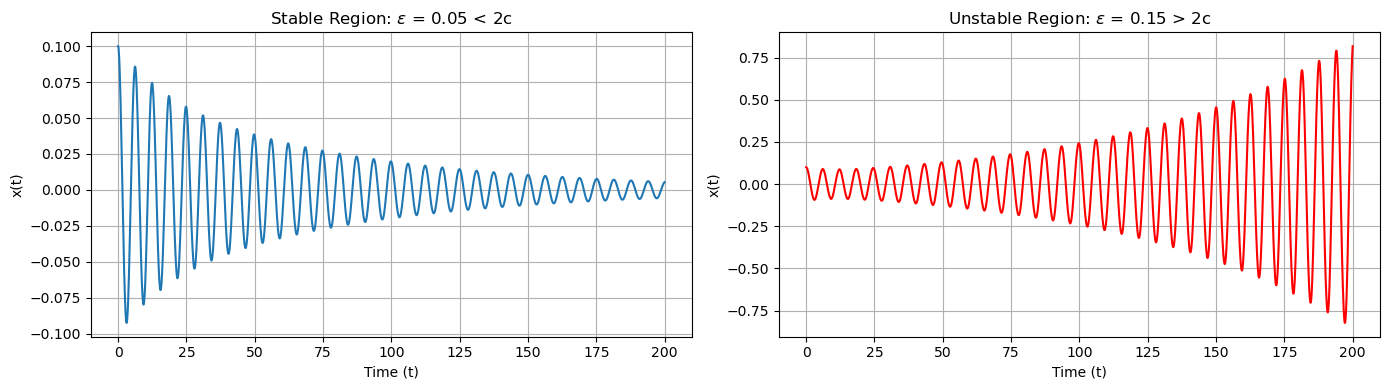

In [ ]:
omega_sq = 1.0
c = 0.05
epsilon_stable = 0.05
epsilon_unstable = 0.15

t_span = (0, 200)
t_eval = np.linspace(t_span[0], t_span[1], 2000)
y0 = [0.1, 0.0]

sol_stable = solve_ivp(mathieu_system, t_span, y0, t_eval=t_eval, args=(c, omega_sq, epsilon_stable))
sol_unstable = solve_ivp(mathieu_system, t_span, y0, t_eval=t_eval, args=(c, omega_sq, epsilon_unstable))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(sol_stable.t, sol_stable.y[0])
ax1.set_title(f'Stable Region: $\epsilon$ = {epsilon_stable} < 2c')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('x(t)')

ax2.plot(sol_unstable.t, sol_unstable.y[0], color='red')
ax2.set_title(f'Unstable Region: $\epsilon$ = {epsilon_unstable} > 2c')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('x(t)')

plt.tight_layout()
plt.show()

As expected, the simulation clearly shows that when the parametric forcing $\varepsilon$ overcomes the damping threshold, the trivial solution becomes unstable, and the oscillations grow exponentially. This confirms our predictions from part (b).

### Investigating the Second Resonance Horn ($\omega \approx 2$)

The problem asks if we can find another "resonance horn" for values of $\omega$ close to 2. 
Parametric resonance typically occurs when the forcing frequency (which is 2 in our $\cos 2t$ term) is approximately $\frac{2\omega}{n}$ for integer values of $n$. 
* The primary resonance ($n=1$) occurs at $\omega = 1$.
* The secondary resonance ($n=2$) should occur at $\omega = 2$ (so $\omega^2 = 4$).

To investigate this, we will set $\omega^2 = 4$. To make the instability easy to spot without needing a massive forcing amplitude, we will turn off the damping ($c = 0$) and apply a moderate forcing amplitude $\varepsilon = 0.5$.

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\e'
C:\Users\cvest\AppData\Local\Temp\ipykernel_21812\392110897.py:15: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f'Second Resonance Horn: $\omega^2$ = {omega_sq_2}, $\epsilon$ = {epsilon_2}')
C:\Users\cvest\AppData\Local\Temp\ipykernel_21812\392110897.py:15: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Second Resonance Horn: $\omega^2$ = {omega_sq_2}, $\epsilon$ = {epsilon_2}')


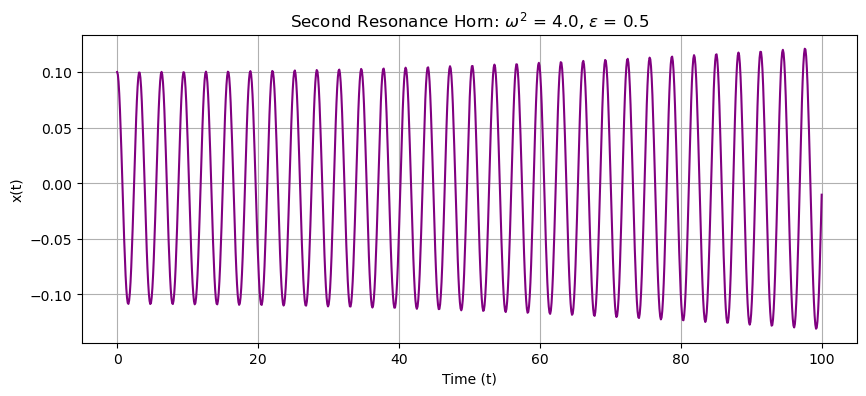

In [ ]:
omega_sq_2 = 4.0
c_0 = 0.0
epsilon_2 = 0.5

t_span_2 = (0, 100)
t_eval_2 = np.linspace(t_span_2[0], t_span_2[1], 1000)

sol_horn2 = solve_ivp(mathieu_system, t_span_2, y0, t_eval=t_eval_2, args=(c_0, omega_sq_2, epsilon_2))

plt.figure(figsize=(10, 4))
plt.plot(sol_horn2.t, sol_horn2.y[0], color='purple')
plt.title(f'Second Resonance Horn: $\omega^2$ = {omega_sq_2}, $\epsilon$ = {epsilon_2}')
plt.xlabel('Time (t)')
plt.ylabel('x(t)')
plt.show()

### Conclusion
The growing envelope of the oscillations in the final plot confirms the presence of a second resonance horn near $\omega = 2$. Unlike the primary resonance at $\omega=1$, which exhibits growth on the order of $\varepsilon$, this secondary resonance is weaker (growth on the order of $\varepsilon^2$) but is still clearly visible when damping is sufficiently low.

# Question 2

## Numerical Investigation of the Perturbed Pendulum
This notebook numerically simulates the motion of a simple pendulum subject to periodic forcing, constant torque, and damping. We will investigate both the autonomous case ($\gamma=0$) and the periodically forced case ($\gamma\neq0$) to verify the theoretical boundaries predicted by the Melnikov method.

First, let's import the necessary libraries.

In [5]:
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

### Defining the System
The equations of motion for our perturbed pendulum are given by:
$$\dot{\theta}=v$$
$$\dot{v}=-\sin\theta+\varepsilon(\beta-\delta v+\gamma\cos t)$$

We will define this continuous-time dynamical system for SciPy's `solve_ivp`. Because the pendulum's position exists on a cylinder, we will also include a helper function to wrap the angle $\theta$ to the interval $[-\pi,\pi]$. This ensures our phase portraits remain localized rather than drifting off to infinity along the $\theta$-axis.

In [ ]:
def forced_pendulum(t, state, eps, beta, delta, gamma):
    theta, v = state
    dtheta = v
    dv = -np.sin(theta) + eps * (beta - delta * v + gamma * np.cos(t))
    return [dtheta, dv]

def wrap_theta(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi

### Autonomous Case Phase Portraits ($\gamma=0$)
In the absence of periodic forcing, the system is autonomous. Our Melnikov analysis predicted a homoclinic bifurcation when the applied torque perfectly balances the energy dissipated by damping over one homoclinic orbit. This occurs at the critical threshold:
$$\beta_c=\frac{4}{\pi}\delta$$

We will simulate three distinct topological regimes by varying $\beta$:
1. $\beta<\beta_c$: Damping dominates. The unstable manifold of the saddle falls inward, and trajectories eventually spiral into a stable sink.
2. $\beta\approx\beta_c$: The homoclinic boundary. The stable and unstable manifolds of the saddle join to form a closed homoclinic loop.
3. $\beta>\beta_c$: Torque dominates. The continuous addition of energy allows the pendulum to overcome top-dead-center, giving birth to a stable running periodic orbit (limit cycle) that encircles the cylinder.

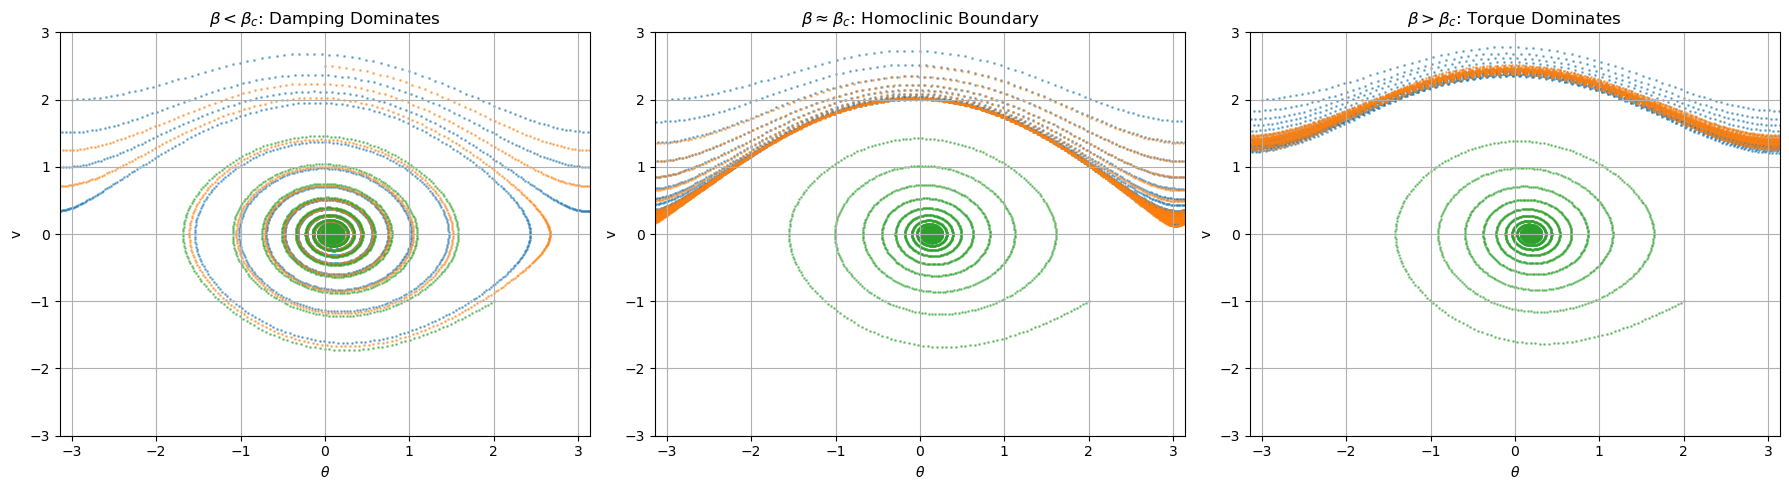

In [ ]:
eps = 0.1
delta = 1.0
gamma = 0.0
beta_c = (4 / np.pi) * delta

betas = [0.8, beta_c, 1.8]
titles = [r'$\beta < \beta_c$: Damping Dominates', 
          r'$\beta \approx \beta_c$: Homoclinic Boundary', 
          r'$\beta > \beta_c$: Torque Dominates']

t_span = (0, 100)
t_eval = np.linspace(t_span[0], t_span[1], 3000)
initial_conditions = [[-3.0, 2.0], [0.0, 2.5], [2.0, -1.0]]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, beta in enumerate(betas):
    ax = axes[i]
    for y0 in initial_conditions:
        sol = solve_ivp(forced_pendulum, t_span, y0, t_eval=t_eval, 
                        args=(eps, beta, delta, gamma))
        theta_wrapped = wrap_theta(sol.y[0])
        ax.scatter(theta_wrapped, sol.y[1], s=1, alpha=0.5)
        
    ax.set_title(titles[i])
    ax.set_xlabel(r'$\theta$')
    ax.set_ylabel('v')
    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

### Periodically Forced Case ($\gamma\neq0$) and Poincaré Maps
When we introduce periodic forcing ($\gamma>0$), the system becomes non-autonomous. The stable and unstable manifolds of the perturbed saddle point can now intersect transversally if the Melnikov function $M(t_0)$ has simple zeros. This transverse intersection creates a homoclinic tangle, leading to topological chaos (a Smale horseshoe).

To visualize this complex behavior, we will construct a Poincaré map. By strobing the system exactly once per forcing period ($T=2\pi$), we project the continuous flow onto a discrete 2D map. The resulting scatter plot will reveal the fractal "footprint" of the chaotic attractor formed by the entangled manifolds.

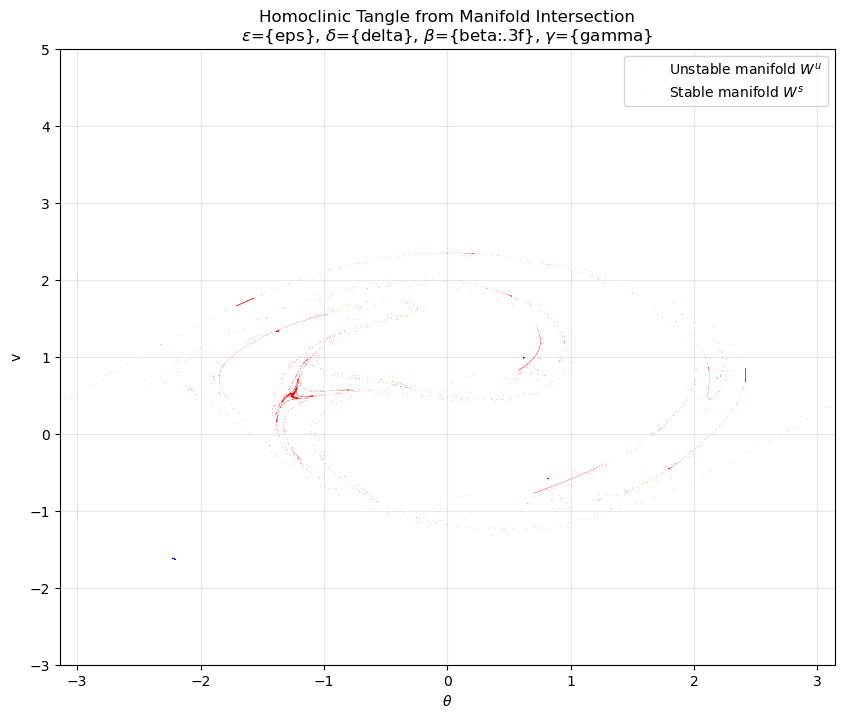

In [ ]:
eps = 0.1
delta = 1.0
beta = (4 / np.pi) * delta
gamma = 5.0

def jacobian_autonomous(theta, v, eps, beta, delta):
    df1_dtheta = 0
    df1_dv = 1
    df2_dtheta = -np.cos(theta) - eps * beta
    df2_dv = -eps * delta
    return np.array([[df1_dtheta, df1_dv], [df2_dtheta, df2_dv]])

J = jacobian_autonomous(np.pi, 0, eps, beta, delta)
vals, vecs = np.linalg.eig(J)

idx_u = np.argmax(np.real(vals))
idx_s = np.argmin(np.real(vals))
v_u = np.real(vecs[:, idx_u])
v_s = np.real(vecs[:, idx_s])

v_u = v_u / np.linalg.norm(v_u)
v_s = v_s / np.linalg.norm(v_s)

eps_seed = 1e-3
n_seeds = 120
n_periods = 100

s_unstable = np.linspace(-eps_seed, eps_seed, n_seeds)
theta_u_init = np.pi + s_unstable * v_u[0]
v_u_init = 0.0 + s_unstable * v_u[1]

theta_s_init = np.pi + s_unstable * v_s[0]
v_s_init = 0.0 + s_unstable * v_s[1]

t_poincare = np.arange(0, n_periods * 2 * np.pi, 2 * np.pi)

theta_u_all = []
v_u_all = []

for i in range(n_seeds):
    sol_u = solve_ivp(forced_pendulum, (0, n_periods * 2 * np.pi), 
                      [theta_u_init[i], v_u_init[i]],
                      t_eval=t_poincare,
                      args=(eps, beta, delta, gamma),
                      rtol=1e-6, atol=1e-7, method='RK45')
    theta_u_all.append(sol_u.y[0])
    v_u_all.append(sol_u.y[1])

theta_u_all = np.hstack(theta_u_all)
v_u_all = np.hstack(v_u_all)

theta_s_all = []
v_s_all = []

for i in range(n_seeds):
    sol_s = solve_ivp(forced_pendulum, (0, -n_periods * 2 * np.pi), 
                      [theta_s_init[i], v_s_init[i]],
                      t_eval=-t_poincare,
                      args=(eps, beta, delta, gamma),
                      rtol=1e-6, atol=1e-7, method='RK45')
    theta_s_all.append(sol_s.y[0])
    v_s_all.append(sol_s.y[1])

theta_s_all = np.hstack(theta_s_all)
v_s_all = np.hstack(v_s_all)

theta_u_wrapped = wrap_theta(theta_u_all)
theta_s_wrapped = wrap_theta(theta_s_all)

plt.figure(figsize=(10, 8))
plt.plot(theta_u_wrapped, v_u_all, ',', color='red', alpha=0.2, label=r'Unstable manifold $W^u$')
plt.plot(theta_s_wrapped, v_s_all, ',', color='blue', alpha=0.2, label=r'Stable manifold $W^s$')
plt.title(f'Homoclinic Tangle from Manifold Intersection\n'
          r'$\epsilon$={eps}, $\delta$={delta}, $\beta$={beta:.3f}, $\gamma$={gamma}')
plt.xlabel(r'$\theta$')
plt.ylabel('v')
plt.xlim(-np.pi, np.pi)
plt.ylim(-3, 5)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Conclusion: Reconciling Theory and Simulation

In this notebook, we utilized numerical simulations to verify the analytical predictions derived from the Melnikov method for the perturbed pendulum system.

1. The Autonomous System ($\gamma = 0$):
Our phase portraits confirm the theoretical stability boundaries. When the constant torque parameter $\beta$ is below the critical threshold ($\beta < \frac{4}{\pi}\delta$), the system dissipates energy, and trajectories spiral into a stable equilibrium. Exactly at the threshold, a homoclinic connection forms. Once the torque exceeds this boundary ($\beta > \frac{4}{\pi}\delta$), we observe the birth of a stable running periodic orbit encircling the cylinder, which perfectly aligns with the predicted homoclinic bifurcation.

2. The Periodically Forced System ($\gamma \neq 0$):
By introducing periodic forcing near the homoclinic boundary, the Melnikov function predicted transverse intersections of the stable and unstable manifolds. The Poincaré map generated in our final simulation provides clear visual evidence of this phenomenon. The resulting scatter plot displays the complex, fractal-like structure of a homoclinic tangle. This confirms the onset of topological chaos (Smale horseshoe dynamics) exactly as predicted by our $\mathcal{O}(\varepsilon)$ perturbation analysis.

Ultimately, these numerical experiments demonstrate the power and accuracy of the Melnikov method in predicting complex global bifurcations and chaotic dynamics in weakly perturbed Hamiltonian systems.